# 05 — Network Analysis
**Project:** Spatial–Temporal Analysis and Demand Forecasting of Ride-Hailing Mobility

**Purpose:** Build a directed mobility graph of NYC taxi zones, compute centrality (in/out degree, betweenness, PageRank), and detect communities with Louvain. Identifies major transportation hubs and movement clusters.

**Output:** Static + interactive graphs saved to `outputs/network/`, centrality + community membership written to PostgreSQL.

**Tables used:** `trip_events`, `taxi_zones`  →  writes `network_flows` (centrality enriched)

## 0 · Setup

In [23]:
!pip install networkx python-louvain pyvis geopandas folium psycopg2-binary sqlalchemy adjustText -q

In [24]:
import os
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import folium
from adjustText import adjust_text
from pyvis.network import Network
from sqlalchemy import create_engine, text

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED', '#0891B2']
BOROUGH_COLORS = {
    'Manhattan': '#2563EB', 'Brooklyn': '#16A34A', 'Queens': '#DC2626',
    'Bronx': '#D97706', 'Staten Island': '#7C3AED', 'EWR': '#0891B2',
}

os.makedirs('outputs/network', exist_ok=True)
print('Setup complete.')

Setup complete.


In [25]:
# ── Database connection ─────────────────────────────────────
PG_HOST = '2.tcp.ngrok.io'
PG_PORT = 28535
PG_DB   = 'rides'
PG_USER = 'rides'
PG_PASS = 'rides'

engine = create_engine(
    f'postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}',
    pool_pre_ping=True,
)

with engine.connect() as conn:
    n = conn.execute(text('SELECT COUNT(*) FROM trip_events')).scalar()
    print(f'trip_events rows: {n:,}')

trip_events rows: 1,666,005


## 1 · Load OD Flow Data

Aggregate trip records into directed origin-destination edges. The graph is built from `trip_events` (not `network_flows`, which is windowed for streaming) to get the full-period structure for community detection.

In [4]:
# Aggregate OD pairs over the full period
od_sql = """
SELECT
    pu_zone_id   AS origin,
    do_zone_id   AS dest,
    COUNT(*)     AS trip_count,
    AVG(trip_miles)    AS avg_miles,
    AVG(trip_time_min) AS avg_minutes
FROM trip_events
WHERE pu_zone_id IS NOT NULL
  AND do_zone_id IS NOT NULL
  AND pu_zone_id != do_zone_id          -- exclude same-zone trips
GROUP BY pu_zone_id, do_zone_id
HAVING COUNT(*) >= 10                   -- prune rare edges (noise)
ORDER BY trip_count DESC
"""
od_df = pd.read_sql(od_sql, engine)
print(f'OD edges loaded: {len(od_df):,}')
print(f'Top 5 edges:')
print(od_df.head(5).to_string(index=False))

OD edges loaded: 17,581
Top 5 edges:
 origin  dest  trip_count  avg_miles  avg_minutes
    132   265        7067  28.073070    50.493529
    138   265        4393  26.256351    45.416841
    216   132        2006   2.886128     8.659588
    161   265        1712  18.218857    39.710855
    215   130        1710   1.307457     8.392388


In [5]:
# Load zone metadata (names, borough, centroids) for labelling
zones_sql = """
SELECT zone_id, zone_name, borough, centroid_lat, centroid_lon
FROM taxi_zones
WHERE borough != 'Unknown'
"""
zones_df = pd.read_sql(zones_sql, engine)
zones_df = zones_df.set_index('zone_id')
print(f'Zones: {len(zones_df)}')

Zones: 263


## 2 · Build Directed Graph

In [6]:
# DiGraph: nodes = zones, edges = OD flows weighted by trip count
G = nx.DiGraph()

# Add nodes with attributes
for zid, row in zones_df.iterrows():
    G.add_node(
        int(zid),
        name=row['zone_name'],
        borough=row['borough'],
        lat=row['centroid_lat'],
        lon=row['centroid_lon'],
    )

# Add weighted edges
for _, row in od_df.iterrows():
    G.add_edge(
        int(row['origin']),
        int(row['dest']),
        weight=int(row['trip_count']),
        miles=float(row['avg_miles']) if pd.notna(row['avg_miles']) else 0,
    )

# Drop isolated nodes (no demand)
G.remove_nodes_from([n for n in list(G.nodes) if G.degree(n) == 0])

print(f'Nodes:    {G.number_of_nodes()}')
print(f'Edges:    {G.number_of_edges():,}')
print(f'Density:  {nx.density(G):.4f}')
print(f'Avg in-degree:  {sum(dict(G.in_degree()).values()) / G.number_of_nodes():.1f}')
print(f'Avg out-degree: {sum(dict(G.out_degree()).values()) / G.number_of_nodes():.1f}')

Nodes:    256
Edges:    17,581
Density:  0.2693
Avg in-degree:  68.7
Avg out-degree: 68.7


## 3 · Centrality Metrics

Four metrics, each capturing a different notion of "important zone":
- **In-degree (weighted):** total inbound trip volume — major destination zones
- **Out-degree (weighted):** total outbound trip volume — major origin zones
- **Betweenness:** zones that lie on many shortest paths — transit "bridges"
- **PageRank:** importance weighted by importance of neighbours

In [7]:
# Weighted degrees (raw trip counts)
in_deg  = dict(G.in_degree(weight='weight'))
out_deg = dict(G.out_degree(weight='weight'))

# Betweenness — use unweighted shortest paths for speed (weighted is O(n^3))
# For a directed graph of ~250 nodes this completes in seconds
betweenness = nx.betweenness_centrality(G, normalized=True)

# PageRank — captures hub importance with directional flow
pagerank = nx.pagerank(G, weight='weight', alpha=0.85)

centrality_df = pd.DataFrame({
    'zone_id':     list(G.nodes),
    'in_degree':   [in_deg[n] for n in G.nodes],
    'out_degree':  [out_deg[n] for n in G.nodes],
    'betweenness': [betweenness[n] for n in G.nodes],
    'pagerank':    [pagerank[n] for n in G.nodes],
})
centrality_df = centrality_df.merge(
    zones_df.reset_index()[['zone_id', 'zone_name', 'borough']],
    on='zone_id', how='left',
)
# Drop unknown/NA zones that crept in via OD data but lack metadata
centrality_df = centrality_df.dropna(subset=['zone_name', 'borough']).reset_index(drop=True)
print(f'Centrality computed for {len(centrality_df)} zones')

Centrality computed for 255 zones


In [8]:
# Top 10 by each metric
for metric in ['in_degree', 'out_degree', 'betweenness', 'pagerank']:
    print(f'\n=== Top 10 by {metric} ===')
    top = centrality_df.nlargest(10, metric)[['zone_name', 'borough', metric]]
    print(top.to_string(index=False))


=== Top 10 by in_degree ===
                zone_name   borough  in_degree
        LaGuardia Airport    Queens      38508
              JFK Airport    Queens      36601
           Midtown Center Manhattan      20760
      Crown Heights North  Brooklyn      19239
Times Sq/Theatre District Manhattan      18267
             East Chelsea Manhattan      17301
West Chelsea/Hudson Yards Manhattan      17047
             Midtown East Manhattan      15528
     TriBeCa/Civic Center Manhattan      15118
              Murray Hill Manhattan      14462

=== Top 10 by out_degree ===
                zone_name   borough  out_degree
        LaGuardia Airport    Queens       37199
              JFK Airport    Queens       35115
           Midtown Center Manhattan       21495
Times Sq/Theatre District Manhattan       19670
      Crown Heights North  Brooklyn       18581
West Chelsea/Hudson Yards Manhattan       17693
             East Chelsea Manhattan       17650
     TriBeCa/Civic Center Manhattan     

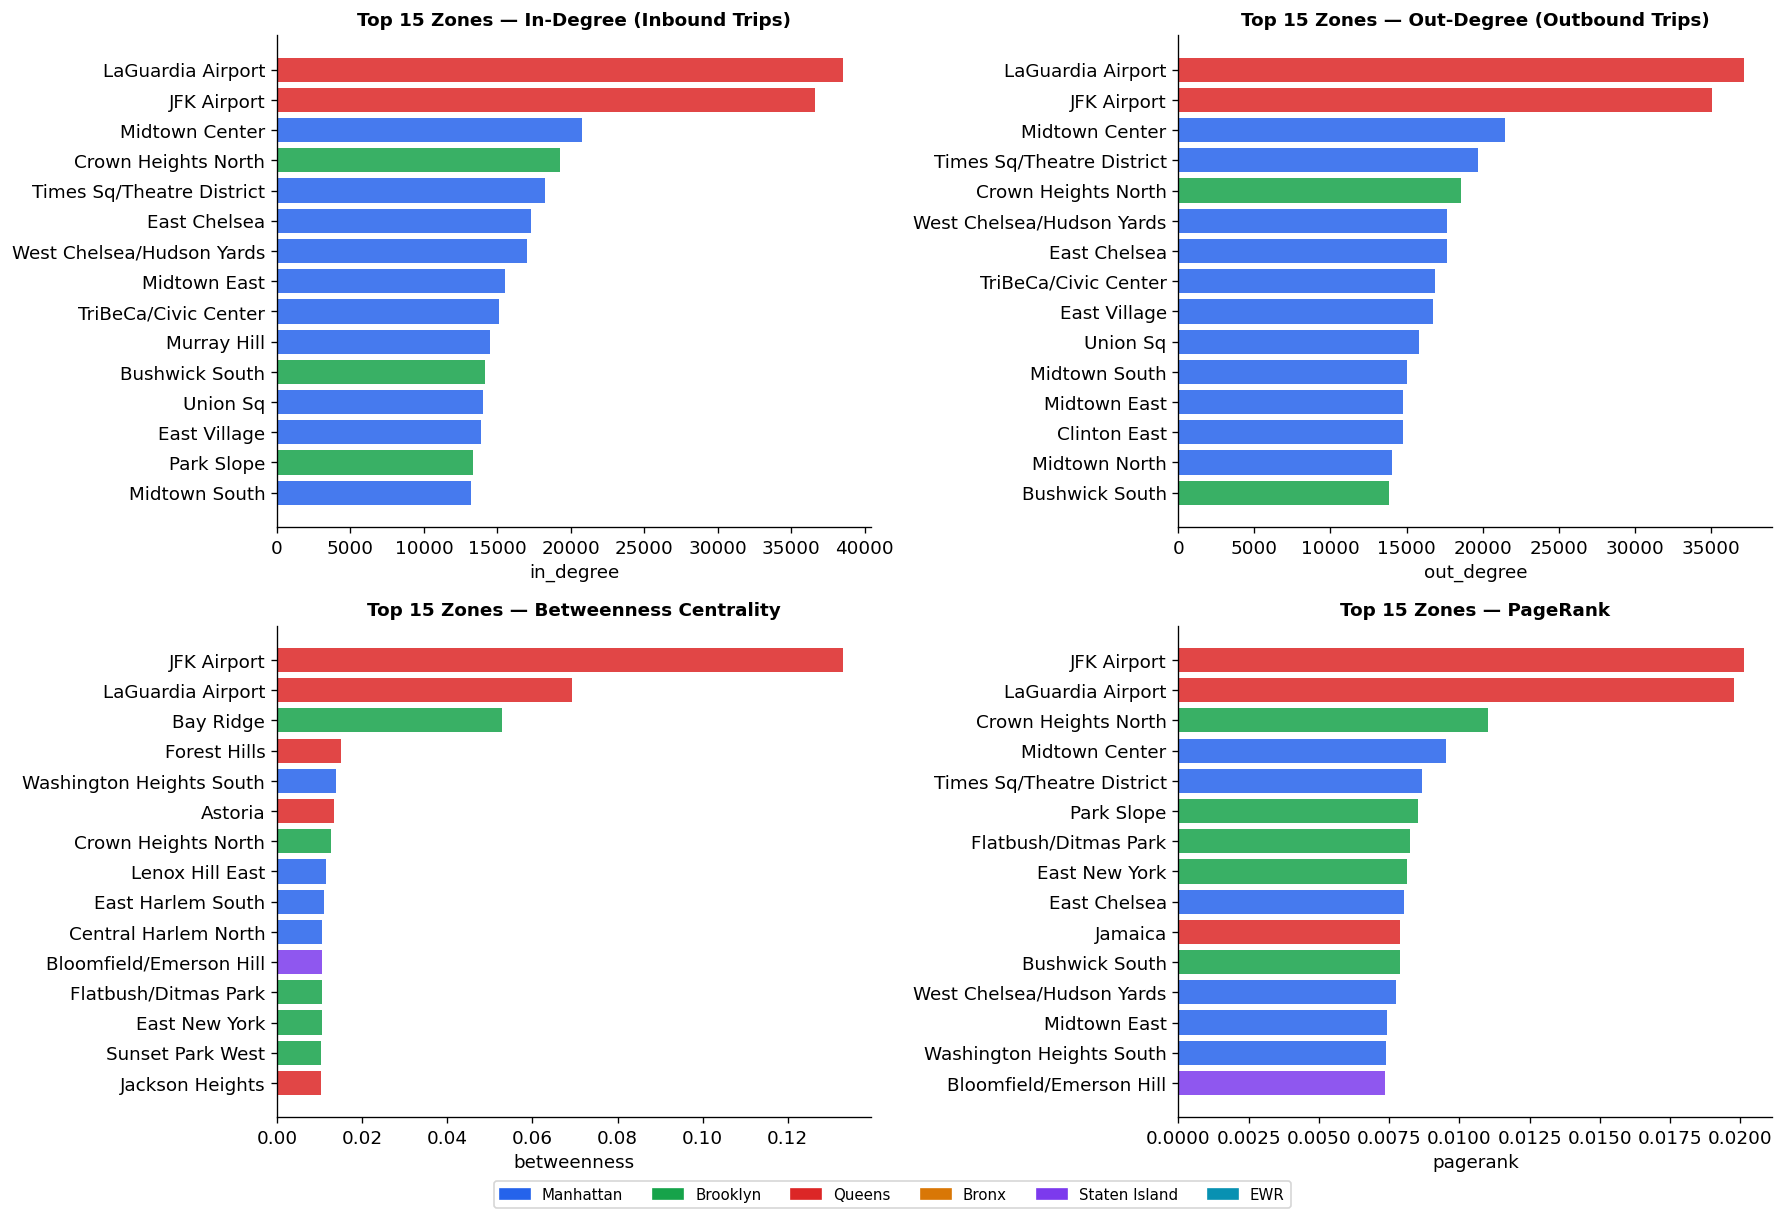

In [9]:
# Plot top 15 zones by each metric (4 subplots)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics = [
    ('in_degree',   'In-Degree (Inbound Trips)',  PALETTE[0]),
    ('out_degree',  'Out-Degree (Outbound Trips)', PALETTE[1]),
    ('betweenness', 'Betweenness Centrality',     PALETTE[2]),
    ('pagerank',    'PageRank',                   PALETTE[3]),
]

for ax, (metric, title, color) in zip(axes.flat, metrics):
    top = centrality_df.nlargest(15, metric).iloc[::-1]
    colors = [BOROUGH_COLORS.get(b, '#999') for b in top['borough']]
    ax.barh(top['zone_name'], top[metric], color=colors, alpha=0.85)
    ax.set_xlabel(metric)
    ax.set_title(f'Top 15 Zones — {title}', fontsize=11, fontweight='bold')

# Single legend for borough colours
legend_patches = [mpatches.Patch(color=c, label=b) for b, c in BOROUGH_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=6, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('outputs/network/01_centrality_top15.png', bbox_inches='tight', dpi=150)
plt.show()

## 4 · Louvain Community Detection

Louvain works on undirected weighted graphs. We collapse the directed graph by summing reciprocal flows, then partition nodes by modularity maximisation.

In [10]:
G_undirected = nx.Graph()
for u, v, data in G.edges(data=True):
    w = data['weight']
    if G_undirected.has_edge(u, v):
        G_undirected[u][v]['weight'] += w
    else:
        G_undirected.add_edge(u, v, weight=w)

print(f'Undirected: {G_undirected.number_of_nodes()} nodes, '
      f'{G_undirected.number_of_edges():,} edges')

# Built-in Louvain (NetworkX ≥ 2.7) — returns list of sets
communities = nx.community.louvain_communities(G_undirected, weight='weight', seed=42)
partition = {node: cid for cid, comm in enumerate(communities) for node in comm}
modularity = nx.community.modularity(G_undirected, communities, weight='weight')

centrality_df['community'] = centrality_df['zone_id'].map(partition)

n_communities = centrality_df['community'].nunique()
print(f'\nCommunities detected: {n_communities}')
print(f'Modularity:           {modularity:.4f}  (>0.3 indicates real structure)')

Undirected: 256 nodes, 10,035 edges

Communities detected: 5
Modularity:           0.4928  (>0.3 indicates real structure)


In [11]:
# Community size distribution
comm_sizes = centrality_df['community'].value_counts().sort_values(ascending=False)
print('=== Community sizes ===')
print(comm_sizes.head(10).to_string())

# Show members of the 5 largest communities
print('\n=== Top zones in 5 largest communities ===')
for cid in comm_sizes.head(5).index:
    members = centrality_df[centrality_df['community'] == cid]\
        .nlargest(5, 'in_degree')[['zone_name', 'borough']]
    boros = centrality_df[centrality_df['community'] == cid]['borough'].value_counts()
    print(f'\nCommunity {cid}  ({comm_sizes[cid]} zones, dominant: {boros.index[0]})')
    print(members.to_string(index=False))

=== Community sizes ===
community
4    64
2    63
0    58
1    51
3    19

=== Top zones in 5 largest communities ===

Community 4  (64 zones, dominant: Queens)
                     zone_name borough
                   JFK Airport  Queens
                       Jamaica  Queens
                       Astoria  Queens
Long Island City/Hunters Point  Queens
                     Sunnyside  Queens

Community 2  (63 zones, dominant: Brooklyn)
           zone_name  borough
 Crown Heights North Brooklyn
      Bushwick South Brooklyn
          Park Slope Brooklyn
       East New York Brooklyn
Flatbush/Ditmas Park Brooklyn

Community 0  (58 zones, dominant: Bronx)
               zone_name   borough
Washington Heights South Manhattan
    Central Harlem North Manhattan
       East Harlem South Manhattan
       East Harlem North Manhattan
  Mott Haven/Port Morris     Bronx

Community 1  (51 zones, dominant: Manhattan)
                zone_name   borough
        LaGuardia Airport    Queens
          

## 5 · Visualization

In [12]:
# ── 5a · Choropleth coloured by community ───────────────────
# Build a quick GeoDataFrame from centroids → Voronoi-ish doesn't help here.
# Instead, just plot zones using the shapefile if available; otherwise scatter.

import zipfile, pathlib
from google.colab import drive

drive.mount('/content/drive', force_remount=False)
DRIVE_ZIP = pathlib.Path('/content/drive/MyDrive/Colab Notebooks/shapefile_upload.zip')
SHP_DIR   = pathlib.Path('data/taxi_zones')
SHP_FILE  = SHP_DIR / 'taxi_zones.shp'
SHP_DIR.mkdir(parents=True, exist_ok=True)

if not SHP_FILE.exists() and DRIVE_ZIP.exists():
    with zipfile.ZipFile(DRIVE_ZIP, 'r') as z:
        z.extractall(SHP_DIR)

gdf = gpd.read_file(SHP_FILE).to_crs(4326).rename(columns={'LocationID': 'zone_id'})
gdf = (
    gdf.drop(columns=['borough'], errors='ignore')
       .merge(centrality_df, on='zone_id', how='left')
)
print(f'Joined: {len(gdf)} zones, {gdf.community.notna().sum()} with community')

Mounted at /content/drive
Joined: 263 zones, 255 with community


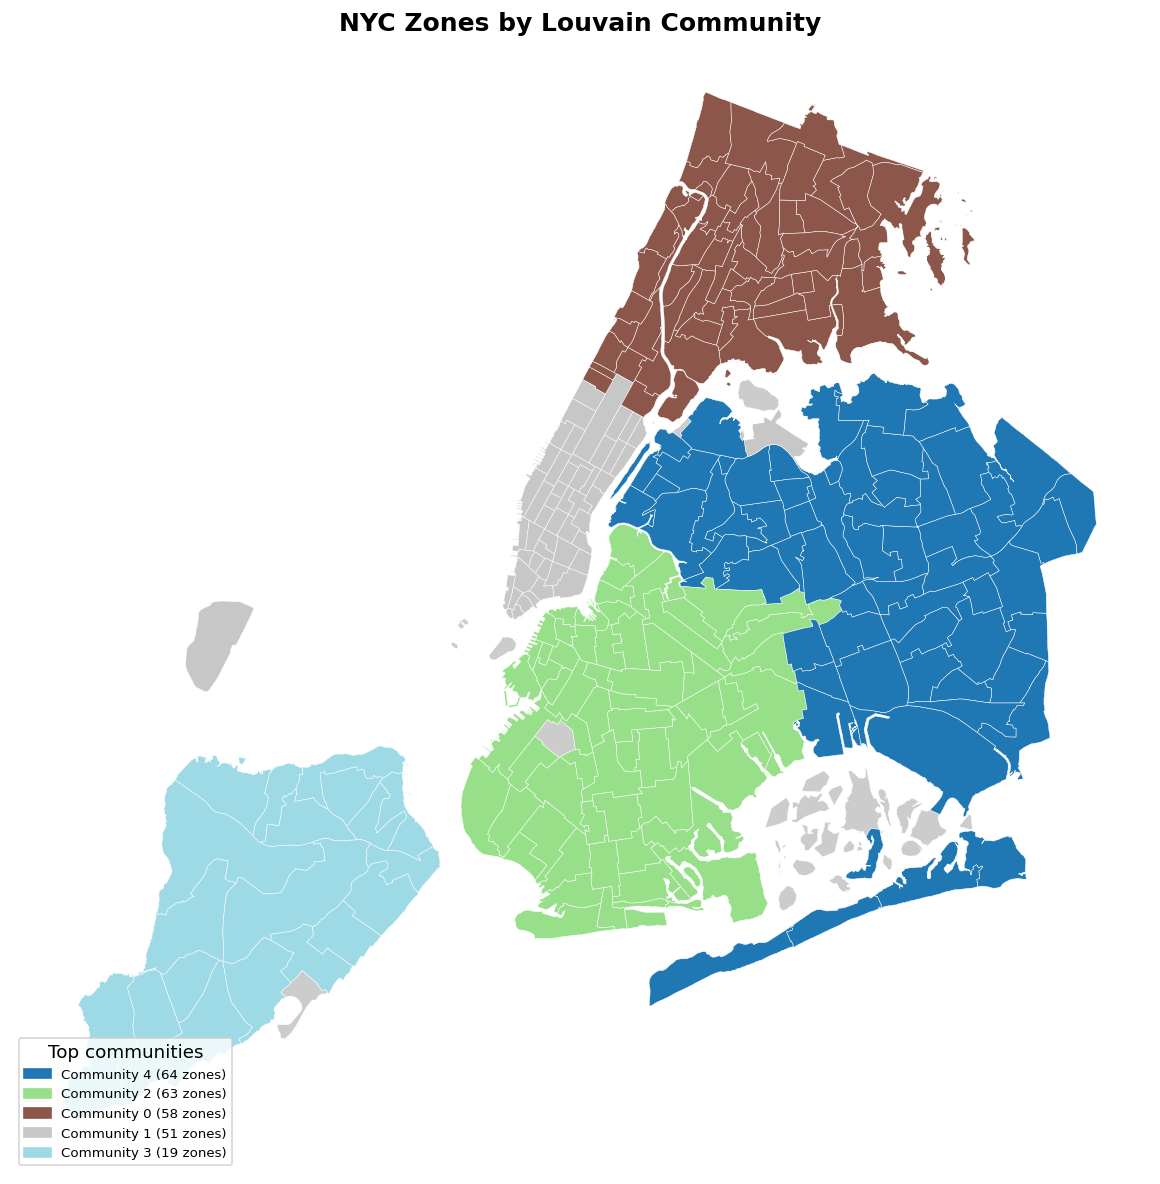

In [13]:
# Pick a discrete colour for each community (recycle a tab20 palette)
from matplotlib import colormaps, colors as mcolors

n_show = min(int(centrality_df['community'].nunique()), 20)
top_communities = comm_sizes.head(n_show).index.tolist()
cmap = colormaps.get_cmap('tab20').resampled(len(top_communities))
comm_color = {cid: mcolors.to_hex(cmap(i)) for i, cid in enumerate(top_communities)}

def color_for(cid):
    return comm_color.get(cid, '#CCCCCC')

gdf['comm_color'] = gdf['community'].map(color_for).fillna('#EEEEEE')

fig, ax = plt.subplots(figsize=(12, 10))
gdf.plot(ax=ax, color=gdf['comm_color'], edgecolor='white', linewidth=0.3)
ax.set_title('NYC Zones by Louvain Community', fontsize=15, fontweight='bold')
ax.set_axis_off()

legend_patches = [
    mpatches.Patch(color=comm_color[cid], label=f'Community {cid} ({comm_sizes[cid]} zones)')
    for cid in top_communities[:10]
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=8, title='Top communities')

plt.tight_layout()
plt.savefig('outputs/network/02_communities_map.png', bbox_inches='tight', dpi=150)
plt.show()

Drawing 100 edges, 69 nodes


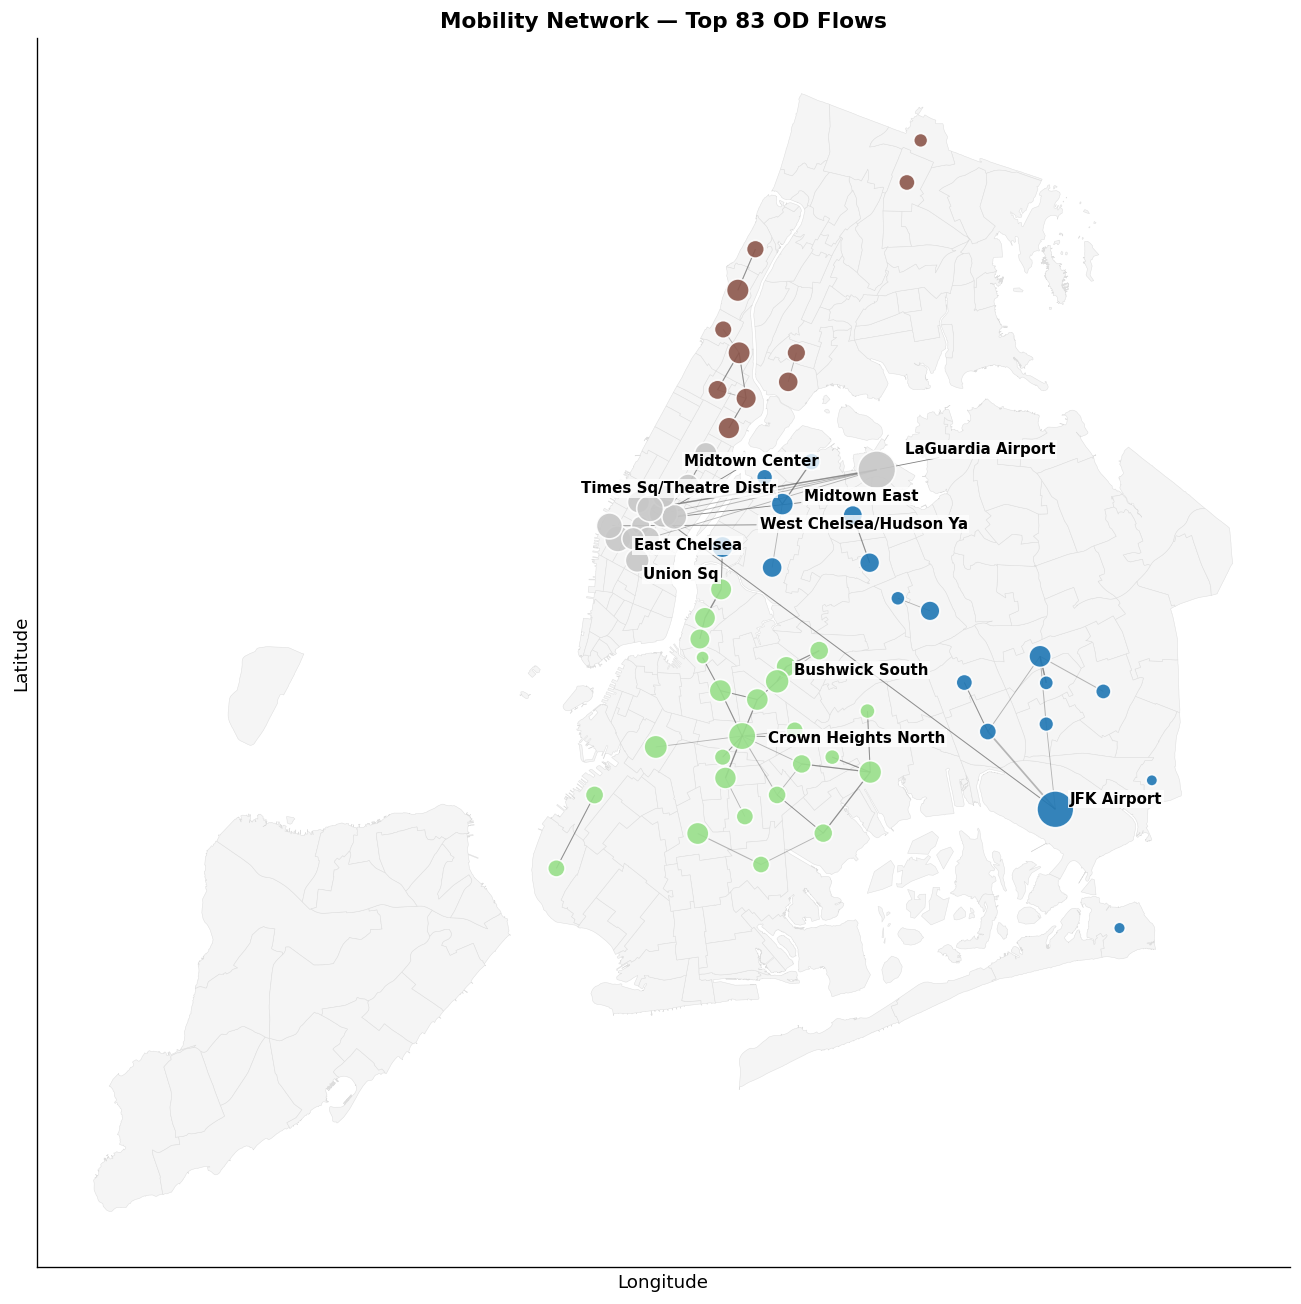

In [14]:
# ── 5b · Static network plot — top edges only ───────────────
# Take top N edges directly (more robust than percentile on small graphs)
TOP_EDGES = min(100, G.number_of_edges())
sorted_edges = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
top_edges = sorted_edges[:TOP_EDGES]

G_top = G.edge_subgraph([(u, v) for u, v, _ in top_edges]).copy()
print(f'Drawing {G_top.number_of_edges()} edges, {G_top.number_of_nodes()} nodes')

# Geographic layout from centroids — filter NaN coordinates
pos = {n: (G.nodes[n]['lon'], G.nodes[n]['lat']) for n in G_top.nodes
       if G.nodes[n].get('lon') is not None
       and not pd.isna(G.nodes[n].get('lon'))}
G_top = G_top.subgraph(list(pos.keys())).copy()

max_in   = max(in_deg.values()) if in_deg else 1
max_edge = max(d['weight'] for _, _, d in top_edges)

node_size  = [in_deg.get(n, 0) / max_in * 800 + 30 for n in G_top.nodes]
node_color = [color_for(partition.get(n, -1)) for n in G_top.nodes]
edge_width = [G_top[u][v]['weight'] / max_edge * 3 + 0.2 for u, v in G_top.edges]
edge_alpha = [G_top[u][v]['weight'] / max_edge * 0.6 + 0.1 for u, v in G_top.edges]

fig, ax = plt.subplots(figsize=(13, 11))
# Draw light zone outlines for geographic context
gdf.plot(ax=ax, color='#F5F5F5', edgecolor='#DDDDDD', linewidth=0.3, zorder=0)

nx.draw_networkx_edges(G_top, pos, ax=ax, width=edge_width,
                       alpha=0.4, edge_color='#555', arrows=False)
nx.draw_networkx_nodes(G_top, pos, ax=ax, node_size=node_size,
                       node_color=node_color, alpha=0.9,
                       edgecolors='white', linewidths=1.0)

# Label only the top 10 hubs
top_hubs = sorted(G_top.nodes, key=lambda n: in_deg.get(n, 0), reverse=True)[:10]
labels = {n: G.nodes[n]['name'][:18] for n in top_hubs}
texts = []
for n in top_hubs:
    x, y = pos[n]
    texts.append(ax.text(x, y, G.nodes[n]['name'][:22], fontsize=9, fontweight='bold',
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1)))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

ax.set_aspect(1.3)  # correct lat/lon distortion at NYC's latitude
ax.set_title(f'Mobility Network — Top {G_top.number_of_edges()} OD Flows',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('outputs/network/03_network_top_edges.png', bbox_inches='tight', dpi=150)
plt.show()

In [15]:
# ── 5c · Interactive network (pyvis) ────────────────────────
net = Network(height='700px', width='100%', bgcolor='#ffffff',
              font_color='#222', directed=True, notebook=True, cdn_resources='remote')

# Limit to top 50 hubs by PageRank for a readable interactive view
top50 = centrality_df.nlargest(50, 'pagerank')['zone_id'].tolist()
G_sub = G.subgraph(top50).copy()

for n in G_sub.nodes:
    net.add_node(
        int(n),
        label=G.nodes[n]['name'][:20],
        title=f"{G.nodes[n]['name']}<br>Borough: {G.nodes[n]['borough']}<br>"
              f"PageRank: {pagerank[n]:.4f}<br>Community: {partition.get(n)}",
        color=color_for(partition.get(n, -1)),
        value=pagerank[n] * 1000,
    )
for u, v, d in G_sub.edges(data=True):
    net.add_edge(int(u), int(v), value=d['weight'] / 10, title=f"{d['weight']:,} trips")

net.set_options("""
{
  "physics": {"barnesHut": {"gravitationalConstant": -8000, "springLength": 120}},
  "edges":   {"smooth": false, "color": {"opacity": 0.3}}
}
""")
net.save_graph('outputs/network/04_network_interactive.html')
print('Saved: outputs/network/04_network_interactive.html')

Saved: outputs/network/04_network_interactive.html


In [16]:
m = folium.Map(location=[40.75, -73.97], zoom_start=11, tiles='CartoDB positron')

folium.GeoJson(
    gdf[['geometry', 'zone_name', 'borough', 'community', 'comm_color']],
    style_function=lambda f: {
        'fillColor':   f['properties']['comm_color'],
        'color':       '#ffffff',
        'weight':      0.4,
        'fillOpacity': 0.6,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['zone_name', 'borough', 'community'],
        aliases=['Zone', 'Borough', 'Community'],
    ),
).add_to(m)

# Filter top flows to those whose origin AND dest are in zones_df
valid_ids = set(zones_df.index)
top_flows = od_df[od_df['origin'].isin(valid_ids) & od_df['dest'].isin(valid_ids)].head(30)
max_w = top_flows['trip_count'].max()

for _, row in top_flows.iterrows():
    o = zones_df.loc[row['origin']]
    d = zones_df.loc[row['dest']]
    if pd.isna(o.centroid_lat) or pd.isna(d.centroid_lat):
        continue
    folium.PolyLine(
        [(o.centroid_lat, o.centroid_lon), (d.centroid_lat, d.centroid_lon)],
        color='#DC2626',
        weight=row['trip_count'] / max_w * 6 + 0.5,
        opacity=0.6,
        tooltip=f"{o.zone_name} → {d.zone_name}: {row['trip_count']:,} trips",
    ).add_to(m)

m.save('outputs/network/05_flows_map_interactive.html')
print('Saved: outputs/network/05_flows_map_interactive.html')
m

Output hidden; open in https://colab.research.google.com to view.

## 6 · Save Results to PostgreSQL

Writes per-zone centrality and community assignment. Schema follows the spec for `network_flows` but extends with `community` since Louvain results aren't in the original ER diagram — Grafana's network panel can join on `zone_id` for colouring.

In [17]:
# The spec network_flows is OD-edge-level; for per-zone centrality
# we create network_centrality as a companion table.
create_sql = """
CREATE TABLE IF NOT EXISTS network_centrality (
    id              BIGSERIAL,
    analysis_time   TIMESTAMPTZ NOT NULL DEFAULT NOW(),
    zone_id         INTEGER REFERENCES taxi_zones(zone_id),
    in_degree       BIGINT,
    out_degree      BIGINT,
    betweenness     FLOAT,
    pagerank        FLOAT,
    community       INTEGER,
    PRIMARY KEY (id, analysis_time)
);
SELECT create_hypertable('network_centrality', 'analysis_time',
                         chunk_time_interval => INTERVAL '1 day',
                         if_not_exists => TRUE);
CREATE INDEX IF NOT EXISTS idx_network_centrality_zone
    ON network_centrality (zone_id, analysis_time DESC);
"""
with engine.connect() as conn:
    for stmt in create_sql.strip().split(';'):
        if stmt.strip():
            conn.execute(text(stmt))
    conn.commit()
print('network_centrality hypertable ready.')

network_centrality hypertable ready.


In [18]:
# Also populate network_flows with the OD edges + node-level centrality joined
create_flows_sql = """
CREATE TABLE IF NOT EXISTS network_flows (
    id               BIGSERIAL,
    time_window      TIMESTAMPTZ NOT NULL DEFAULT NOW(),
    origin_zone_id   INTEGER REFERENCES taxi_zones(zone_id),
    dest_zone_id     INTEGER REFERENCES taxi_zones(zone_id),
    trip_count       INTEGER,
    in_degree        BIGINT,
    out_degree       BIGINT,
    betweenness      FLOAT,
    PRIMARY KEY (id, time_window)
);
SELECT create_hypertable('network_flows', 'time_window',
                         chunk_time_interval => INTERVAL '1 day',
                         if_not_exists => TRUE);
"""
with engine.connect() as conn:
    for stmt in create_flows_sql.strip().split(';'):
        if stmt.strip():
            conn.execute(text(stmt))
    conn.commit()
print('network_flows hypertable ready.')

network_flows hypertable ready.


In [19]:
from datetime import datetime, timezone
run_time = datetime.now(timezone.utc)

# Write centrality (one row per zone)
centrality_out = centrality_df[['zone_id', 'in_degree', 'out_degree',
                                 'betweenness', 'pagerank', 'community']].copy()
centrality_out['analysis_time'] = run_time
centrality_out['in_degree']  = centrality_out['in_degree'].astype('int64')
centrality_out['out_degree'] = centrality_out['out_degree'].astype('int64')
centrality_out['zone_id']    = centrality_out['zone_id'].astype('int64')
centrality_out['community']  = centrality_out['community'].astype('int64')

centrality_out.to_sql('network_centrality', engine, if_exists='append', index=False)
print(f'Written {len(centrality_out)} centrality rows.')

Written 255 centrality rows.


In [20]:
# Write OD edges (limit to edges with weight in top 5% to keep table small)
edge_threshold = od_df['trip_count'].quantile(0.95)
od_top = od_df[od_df['trip_count'] >= edge_threshold].copy()

flows_out = pd.DataFrame({
    'time_window':    run_time,
    'origin_zone_id': od_top['origin'].astype('int64'),
    'dest_zone_id':   od_top['dest'].astype('int64'),
    'trip_count':     od_top['trip_count'].astype('int64'),
    'in_degree':      od_top['dest'].map(in_deg).astype('int64'),
    'out_degree':     od_top['origin'].map(out_deg).astype('int64'),
    'betweenness':    od_top['origin'].map(betweenness),
})
flows_out.to_sql('network_flows', engine, if_exists='append', index=False)
print(f'Written {len(flows_out)} OD-edge rows (top 5% by volume).')

Written 881 OD-edge rows (top 5% by volume).


## 7 · Summary Findings

In [21]:
print('=' * 60)
print('NETWORK ANALYSIS SUMMARY FINDINGS')
print('=' * 60)

top_in   = centrality_df.nlargest(1, 'in_degree').iloc[0]
top_out  = centrality_df.nlargest(1, 'out_degree').iloc[0]
top_bet  = centrality_df.nlargest(1, 'betweenness').iloc[0]
top_pr   = centrality_df.nlargest(1, 'pagerank').iloc[0]

print(f"""
1. GRAPH STRUCTURE:
   Nodes:    {G.number_of_nodes()}
   Edges:    {G.number_of_edges():,}
   Density:  {nx.density(G):.4f}

2. TOP HUBS:
   Largest destination (in-degree):  {top_in['zone_name']} ({top_in['borough']}) — {top_in['in_degree']:,} trips
   Largest origin (out-degree):      {top_out['zone_name']} ({top_out['borough']}) — {top_out['out_degree']:,} trips
   Biggest "bridge" (betweenness):   {top_bet['zone_name']} ({top_bet['borough']}) — {top_bet['betweenness']:.4f}
   Highest PageRank:                 {top_pr['zone_name']} ({top_pr['borough']}) — {top_pr['pagerank']:.4f}

3. COMMUNITIES:
   Detected:        {n_communities}
   Modularity:      {modularity:.4f}
   Largest comm:    {comm_sizes.iloc[0]} zones (dominated by {centrality_df[centrality_df['community']==comm_sizes.index[0]]['borough'].mode().iloc[0]})

4. OUTPUT FILES:
   outputs/network/01_centrality_top15.png
   outputs/network/02_communities_map.png
   outputs/network/03_network_top_edges.png
   outputs/network/04_network_interactive.html
   outputs/network/05_flows_map_interactive.html

5. DB TABLES WRITTEN:
   network_centrality   ({len(centrality_out)} rows)
   network_flows        ({len(flows_out)} rows, top 5% by volume)
""")

NETWORK ANALYSIS SUMMARY FINDINGS

1. GRAPH STRUCTURE:
   Nodes:    256
   Edges:    17,581
   Density:  0.2693

2. TOP HUBS:
   Largest destination (in-degree):  LaGuardia Airport (Queens) — 38,508 trips
   Largest origin (out-degree):      LaGuardia Airport (Queens) — 37,199 trips
   Biggest "bridge" (betweenness):   JFK Airport (Queens) — 0.1329
   Highest PageRank:                 JFK Airport (Queens) — 0.0201

3. COMMUNITIES:
   Detected:        5
   Modularity:      0.4928
   Largest comm:    64 zones (dominated by Queens)

4. OUTPUT FILES:
   outputs/network/01_centrality_top15.png
   outputs/network/02_communities_map.png
   outputs/network/03_network_top_edges.png
   outputs/network/04_network_interactive.html
   outputs/network/05_flows_map_interactive.html

5. DB TABLES WRITTEN:
   network_centrality   (255 rows)
   network_flows        (881 rows, top 5% by volume)

Next notebook: 06_forecasting.ipynb



In [22]:
import os, shutil
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive', force_remount=False)

DRIVE_OUTPUTS = '/content/drive/MyDrive/Colab Notebooks/ride_hailing_outputs'
os.makedirs(DRIVE_OUTPUTS, exist_ok=True)

n = 0
for root, _, files_ in os.walk('outputs'):
    for f in files_:
        src = os.path.join(root, f)
        rel = os.path.relpath(src, 'outputs')
        dst = os.path.join(DRIVE_OUTPUTS, rel)
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy2(src, dst)
        n += 1

print(f'Synced {n} files to {DRIVE_OUTPUTS}')

Synced 5 files to /content/drive/MyDrive/Colab Notebooks/ride_hailing_outputs


In [26]:
import os
for root, _, files in os.walk('outputs/network'):
    for f in files:
        print(os.path.join(root, f))

outputs/network/05_flows_map_interactive.html
outputs/network/03_network_top_edges.png
outputs/network/01_centrality_top15.png
outputs/network/02_communities_map.png
outputs/network/04_network_interactive.html
